# Spam Email Detection — Slides Chart Generator
**Group 5 | ITM-390 Machine Learning | AUPP**

Upload these files to Colab before running:
- `spam_email.csv`
- `best_lstm.keras`
- `lstm_tokenizer.pkl`

## 0 · Install & Imports

In [1]:
!pip install -q xgboost

import os, re, random, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    classification_report, f1_score
)
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_STATE = 42
MAX_LEN      = 200
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

os.makedirs('charts', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1 · Load Data

In [2]:
df = pd.read_csv('spam_email.csv', encoding='latin-1', on_bad_lines='skip')
df.columns = [c.strip().lower() for c in df.columns]

def to_binary(val):
    v = str(val).strip().lower()
    if v in {'1', 'spam', 'yes', 'junk'}: return 1
    if v in {'0', 'ham', 'no', 'normal', 'notspam'}: return 0
    return np.nan

df['label'] = df['label'].apply(to_binary)
df = df[['text', 'label']].dropna()
df['label'] = df['label'].astype(int)
df['text']  = df['text'].astype(str)
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)

print(f'Rows  : {len(df):,}')
print(f'Spam  : {df["label"].sum():,}  ({df["label"].mean()*100:.1f}%)')
print(f'Ham   : {(df["label"]==0).sum():,}  ({(df["label"]==0).mean()*100:.1f}%)')

Rows  : 80,000
Spam  : 37,709  (47.1%)
Ham   : 42,291  (52.9%)


## 2 · Preprocessing

In [3]:
STOPWORDS = set(stopwords.words('english'))
STOPWORDS.update({'subject', 'email', 'mail', 'com', 'http', 'www', 'nbsp'})
LEET_MAP = str.maketrans({'@':'a','3':'e','1':'i','0':'o','$':'s','7':'t','4':'a'})

def _base_clean(text):
    text = str(text).translate(LEET_MAP).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def preprocess_lstm(text):
    tokens = _base_clean(text).split()
    return ' '.join(t for t in tokens if t not in STOPWORDS and len(t) > 2)

print('Preprocessing... (1–2 min)')
df['lstm_text'] = df['text'].apply(preprocess_lstm)
df = df[df['lstm_text'].str.len() > 0].reset_index(drop=True)
print(f'Done. {len(df):,} rows remaining.')

Preprocessing... (1–2 min)
Done. 79,900 rows remaining.


## 3 · Train/Test Split

In [4]:
y = df['label'].values

(
    X_raw_train, X_raw_test,
    X_lstm_train, X_lstm_test,
    y_train, y_test
) = train_test_split(
    df['text'].values,
    df['lstm_text'].values,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train: {len(y_train):,}  |  Test: {len(y_test):,}')
print(f'Test spam: {y_test.mean()*100:.1f}%')

Train: 63,920  |  Test: 15,980
Test spam: 47.1%


## 4 · Load BiLSTM & Run Inference

In [5]:
model = load_model('best_lstm.keras')
with open('lstm_tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

def tokenize_and_pad(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_test_pad = tokenize_and_pad(X_lstm_test)
proba      = model.predict(X_test_pad, batch_size=256, verbose=1).flatten()
pred       = (proba >= 0.5).astype(int)

print(f'\nF1-Score : {f1_score(y_test, pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, proba):.4f}')
print(classification_report(y_test, pred, target_names=['Ham', 'Spam']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 325ms/step

F1-Score : 0.9746
ROC-AUC  : 0.9957
              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98      8457
        Spam       0.97      0.98      0.97      7523

    accuracy                           0.98     15980
   macro avg       0.98      0.98      0.98     15980
weighted avg       0.98      0.98      0.98     15980



## 5 · Adversarial Robustness Experiment
We simulate three real-world evasion attacks **on spam emails only**:
- **Leet substitution** — `free → fr33`, `money → m0n3y`
- **Symbol insertion** — random `!`, `#`, `*` appended after words
- **Whitespace injection** — `winner → win ner`

The leet-decode step in preprocessing (`LEET_MAP`) directly counters the first attack.

In [6]:
_LEET_ADV = {'a':'@','e':'3','i':'1','o':'0','s':'$','t':'7'}
_SYMBOLS  = ['!','#','*','^','~']

def _leet_sub(text, rate=0.4):
    return ''.join(
        _LEET_ADV.get(c, c) if c in _LEET_ADV and random.random() < rate else c
        for c in text
    )

def _symbol_insert(text, rate=0.2):
    return re.sub(
        r'\b\w{4,}\b',
        lambda m: m.group() + random.choice(_SYMBOLS) if random.random() < rate else m.group(),
        text
    )

def _whitespace_inject(text, rate=0.15):
    def split_w(m):
        w = m.group()
        if len(w) > 4 and random.random() < rate:
            mid = len(w) // 2
            return w[:mid] + ' ' + w[mid:]
        return w
    return re.sub(r'\b\w{5,}\b', split_w, text)

def adversarial_attack(text):
    return _whitespace_inject(_symbol_insert(_leet_sub(text)))

# Apply to spam rows only
X_raw_test_adv = X_raw_test.copy()
spam_idx = np.where(y_test == 1)[0]
for i in spam_idx:
    X_raw_test_adv[i] = adversarial_attack(X_raw_test_adv[i])

print(f'Applied adversarial modifications to {len(spam_idx):,} spam emails.')
print('\nExample — original spam:')
print(f'  {X_raw_test[spam_idx[0]][:120]}')
print('\nAfter adversarial modification:')
print(f'  {X_raw_test_adv[spam_idx[0]][:120]}')

Applied adversarial modifications to 7,523 spam emails.

Example — original spam:
  matt smith enron com bmm b b l escapenumberbz h escapelong escapenumberp bescapenumber b ik escapenumber escapenumberj e

After adversarial modification:
  mat7~ $m1th^ enron com bmm b b l esc@penumberbz h 3sc@p3long 3$c@p3nu mb3rp b3sc^@penu mb3r b 1k esc@p3numb3r* escapenum


In [7]:
# Preprocess adversarial set & run inference
print('Preprocessing adversarial test set...')
X_lstm_test_adv = np.array([preprocess_lstm(t) for t in X_raw_test_adv])

X_adv_pad  = tokenize_and_pad(X_lstm_test_adv)
proba_adv  = model.predict(X_adv_pad, batch_size=256, verbose=1).flatten()
pred_adv   = (proba_adv >= 0.5).astype(int)

f1_orig = f1_score(y_test, pred)
f1_adv  = f1_score(y_test, pred_adv)

print(f'\nOriginal F1    : {f1_orig:.4f}')
print(f'Adversarial F1 : {f1_adv:.4f}')
print(f'F1 Drop        : {f1_orig - f1_adv:+.4f}')

Preprocessing adversarial test set...
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 274ms/step

Original F1    : 0.9746
Adversarial F1 : 0.9765
F1 Drop        : -0.0020


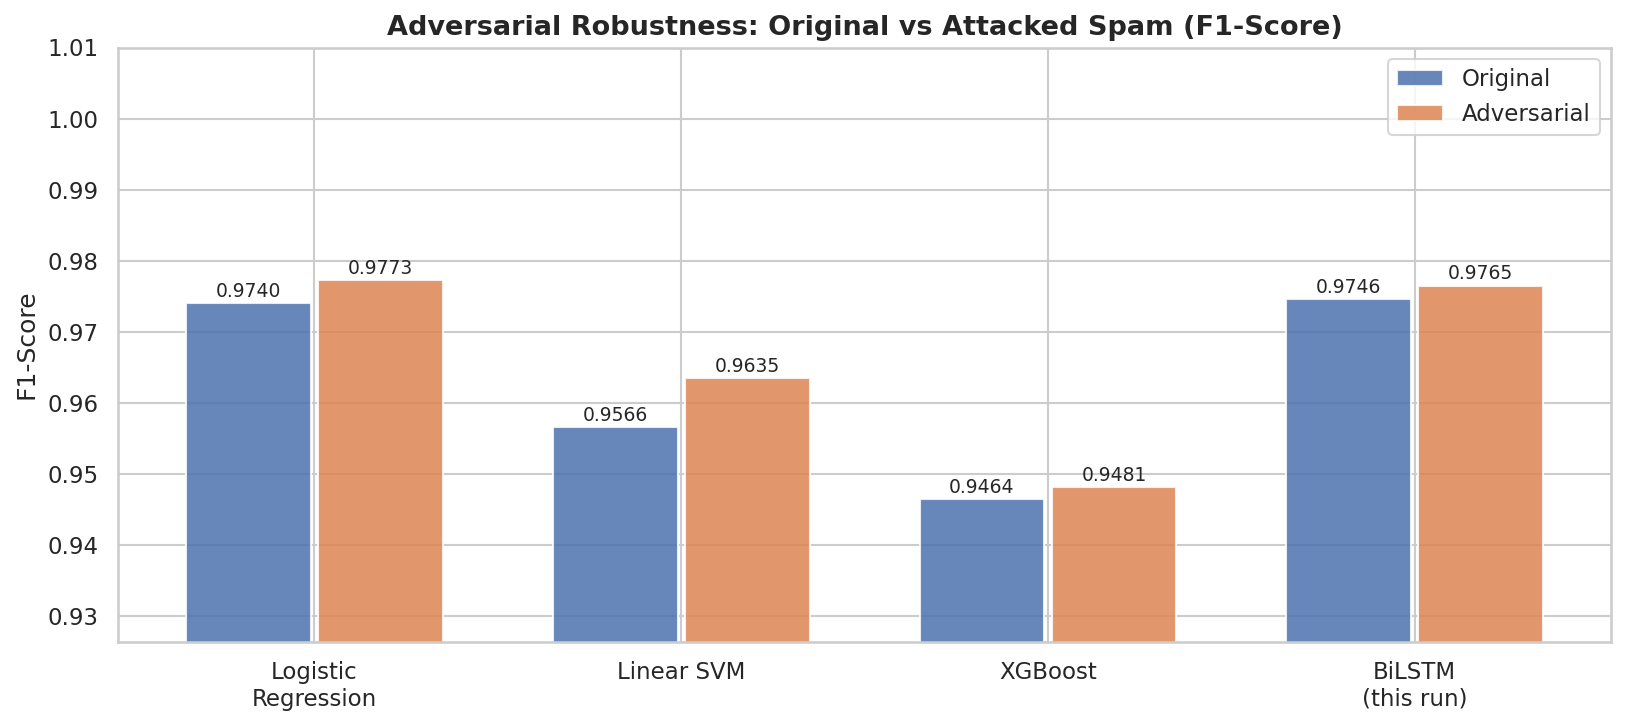

Saved: charts/adversarial_robustness.png


In [8]:
# Adversarial Robustness Chart — all models (classical from Kaggle run)
ADV_ALL = {
    'Logistic\nRegression': {'original': 0.9740, 'adversarial': 0.9773},
    'Linear SVM':           {'original': 0.9566, 'adversarial': 0.9635},
    'XGBoost':              {'original': 0.9464, 'adversarial': 0.9481},
    'BiLSTM\n(this run)':   {'original': round(f1_orig, 4), 'adversarial': round(f1_adv, 4)},
}
model_labels = list(ADV_ALL.keys())
COLOURS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

orig_v = [ADV_ALL[m]['original']    for m in model_labels]
adv_v  = [ADV_ALL[m]['adversarial'] for m in model_labels]
x      = np.arange(len(model_labels))
floor  = min(min(orig_v), min(adv_v)) - 0.02

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - 0.18, orig_v, 0.34, label='Original',    color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + 0.18, adv_v,  0.34, label='Adversarial', color='#DD8452', alpha=0.85)
for bar, val in list(zip(b1, orig_v)) + list(zip(b2, adv_v)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylim(floor, 1.01)
ax.set_ylabel('F1-Score', fontsize=12)
ax.legend(fontsize=11)
ax.set_title('Adversarial Robustness: Original vs Attacked Spam (F1-Score)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/adversarial_robustness.png')
plt.show()
print('Saved: charts/adversarial_robustness.png')

## 6 · Live Prediction Demo
Real email text examples — shows what the model sees in practice.

In [9]:
def predict(raw_text):
    cleaned = preprocess_lstm(raw_text)
    padded  = tokenize_and_pad([cleaned])
    p       = float(model.predict(padded, verbose=0)[0][0])
    label   = 'SPAM' if p >= 0.5 else 'HAM'
    conf    = p if p >= 0.5 else 1 - p
    return label, conf

examples = [
    # Clear spam
    ("Congratulations! You've WON a FREE iPhone 15! Click here NOW to claim your prize!!",        'spam'),
    ("URGENT: Your bank account has been suspended. Verify immediately at http://secure-login.net", 'spam'),
    ("Buy cheap Viagra online — 80% OFF! No prescription needed. Order NOW and save!",              'spam'),
    ("Dear Winner, You have been selected for a $1,000,000 lottery prize. Reply to claim.",         'spam'),
    # Adversarial spam (leet)
    ("C0ngr@ts! Y0u'v3 W0N @ FR33 1Ph0n3! Cl1ck h3r3 N0W t0 cl@1m y0ur pr1z3!!",                 'adversarial spam'),
    ("urg3nt: y0ur b@nk @cc0unt h@s b33n susp3nd3d. v3r1fy @t http://s3cur3-l0g1n.n3t",           'adversarial spam'),
    # Clear ham
    ("Hi John, just a reminder about our team meeting tomorrow at 10am in room 3B.",                'ham'),
    ("Dear Professor, I am writing to ask about the deadline for the ML assignment.",               'ham'),
    ("Please find attached the invoice for your recent purchase. Thank you for your business.",     'ham'),
    ("The quarterly report has been uploaded to the shared drive. Please review by Friday.",        'ham'),
]

print(f'  {"Type":<20}  {"Prediction":<8}  {"Confidence":<12}  Email (first 70 chars)')
print('─' * 105)
for text, kind in examples:
    label, conf = predict(text)
    marker = '✓' if (label == 'SPAM') == ('spam' in kind) else '✗'
    print(f'  {kind:<20}  {label:<8}  {conf*100:>8.1f}%    {marker}  {text[:70]}')

  Type                  Prediction  Confidence    Email (first 70 chars)
─────────────────────────────────────────────────────────────────────────────────────────────────────────
  spam                  SPAM          97.2%    ✓  Congratulations! You've WON a FREE iPhone 15! Click here NOW to claim 
  spam                  SPAM          99.3%    ✓  URGENT: Your bank account has been suspended. Verify immediately at ht
  spam                  SPAM         100.0%    ✓  Buy cheap Viagra online — 80% OFF! No prescription needed. Order NOW a
  spam                  SPAM          99.9%    ✓  Dear Winner, You have been selected for a $1,000,000 lottery prize. Re
  adversarial spam      SPAM          98.3%    ✓  C0ngr@ts! Y0u'v3 W0N @ FR33 1Ph0n3! Cl1ck h3r3 N0W t0 cl@1m y0ur pr1z3
  adversarial spam      SPAM          99.1%    ✓  urg3nt: y0ur b@nk @cc0unt h@s b33n susp3nd3d. v3r1fy @t http://s3cur3-
  ham                   HAM           99.7%    ✓  Hi John, just a reminder about our team meeti

## 7 · Generate All Charts

In [10]:
# Comparison metrics (classical = Kaggle run, BiLSTM = this run)
MODELS  = ['Logistic Regression', 'Linear SVM', 'XGBoost', 'BiLSTM']
COLOURS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

METRICS = {
    'Logistic Regression': {'Accuracy':0.9752,'Precision':0.9632,'Recall':0.9850,'F1-Score':0.9740,'ROC-AUC':0.9966,'Train Time (s)':112.61,'Infer Time (ms)':12.07},
    'Linear SVM':          {'Accuracy':0.9583,'Precision':0.9370,'Recall':0.9770,'F1-Score':0.9566,'ROC-AUC':0.9925,'Train Time (s)':7.00,  'Infer Time (ms)':5.52},
    'XGBoost':             {'Accuracy':0.9481,'Precision':0.9221,'Recall':0.9720,'F1-Score':0.9464,'ROC-AUC':0.9895,'Train Time (s)':162.29,'Infer Time (ms)':166.99},
    'BiLSTM':              {'Accuracy':0.9758,'Precision':0.9656,'Recall':0.9838,'F1-Score':0.9746,'ROC-AUC':0.9957,'Train Time (s)':1038.95,'Infer Time (ms)':5148.0},
}
HISTORY = {
    'loss':         [0.3448, 0.0768, 0.0471, 0.0366, 0.0309],
    'val_loss':     [0.0958, 0.0898, 0.0913, 0.1007, 0.1181],
    'accuracy':     [0.8335, 0.9752, 0.9852, 0.9881, 0.9905],
    'val_accuracy': [0.9662, 0.9734, 0.9734, 0.9725, 0.9692],
}
print('Constants ready.')

Constants ready.


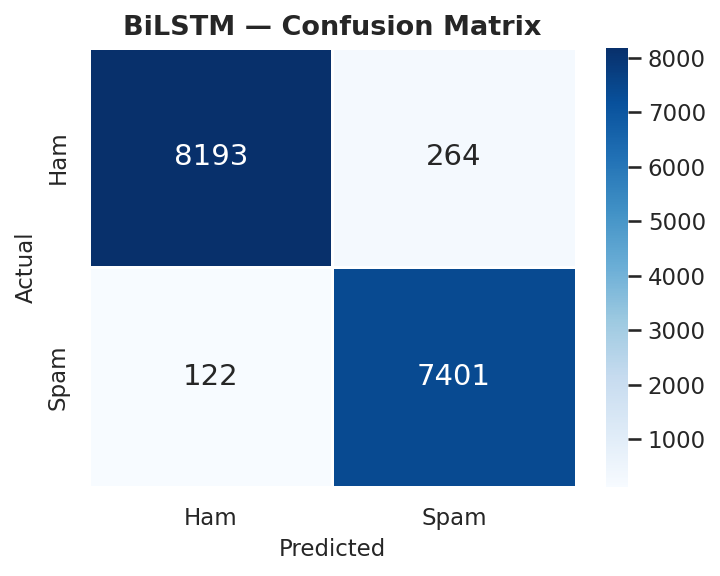

Saved: bilstm_confusion_matrix.png


In [11]:
# Chart — BiLSTM Confusion Matrix
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'],
            linewidths=0.5, annot_kws={'size':14})
ax.set_title('BiLSTM — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.savefig('charts/bilstm_confusion_matrix.png')
plt.show()
print('Saved: bilstm_confusion_matrix.png')

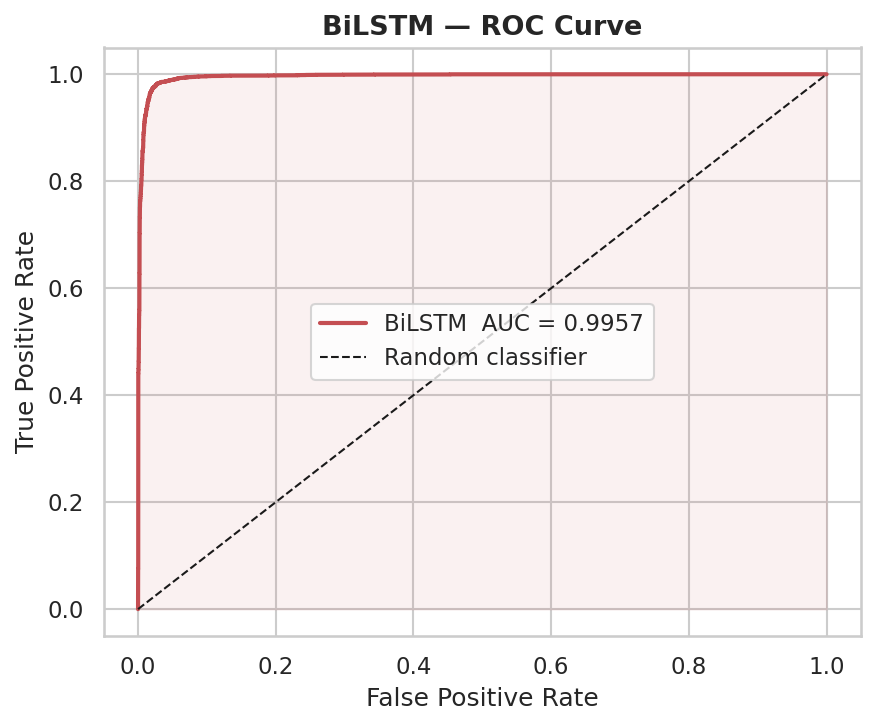

Saved: bilstm_roc_curve.png


In [12]:
# Chart — BiLSTM ROC Curve
fpr, tpr, _ = roc_curve(y_test, proba)
auc_score   = roc_auc_score(y_test, proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#C44E52', lw=2, label=f'BiLSTM  AUC = {auc_score:.4f}')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#C44E52')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('BiLSTM — ROC Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('charts/bilstm_roc_curve.png')
plt.show()
print('Saved: bilstm_roc_curve.png')

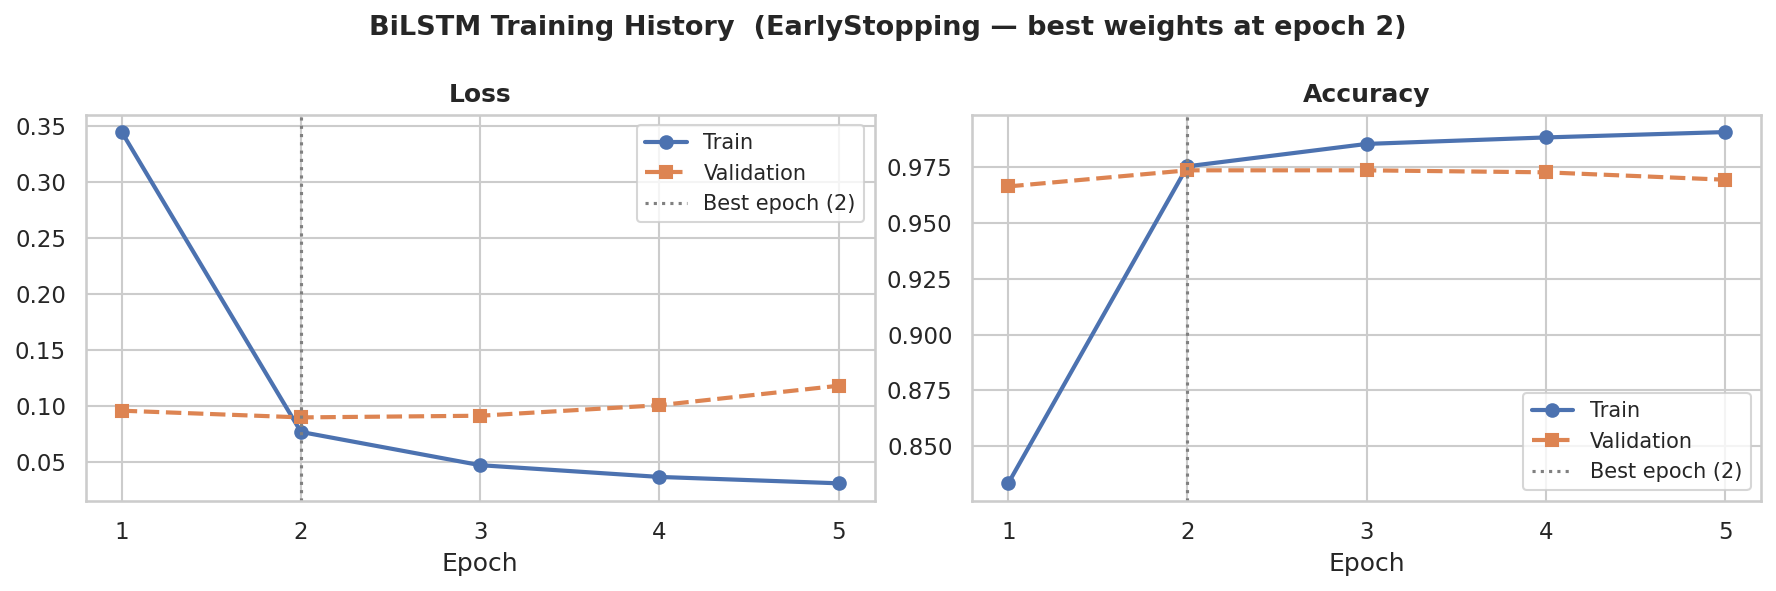

Saved: bilstm_training_history.png


In [13]:
# Chart — BiLSTM Training History
epochs = list(range(1, len(HISTORY['loss']) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel in zip(axes, ['loss','accuracy'], ['Loss','Accuracy']):
    ax.plot(epochs, HISTORY[metric],         'o-',  color='#4C72B0', lw=2, label='Train')
    ax.plot(epochs, HISTORY[f'val_{metric}'],'s--', color='#DD8452', lw=2, label='Validation')
    ax.axvline(2, color='gray', linestyle=':', lw=1.5, label='Best epoch (2)')
    ax.set_title(ylabel, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_xticks(epochs)
    ax.legend(fontsize=10)

plt.suptitle('BiLSTM Training History  (EarlyStopping — best weights at epoch 2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/bilstm_training_history.png')
plt.show()
print('Saved: bilstm_training_history.png')

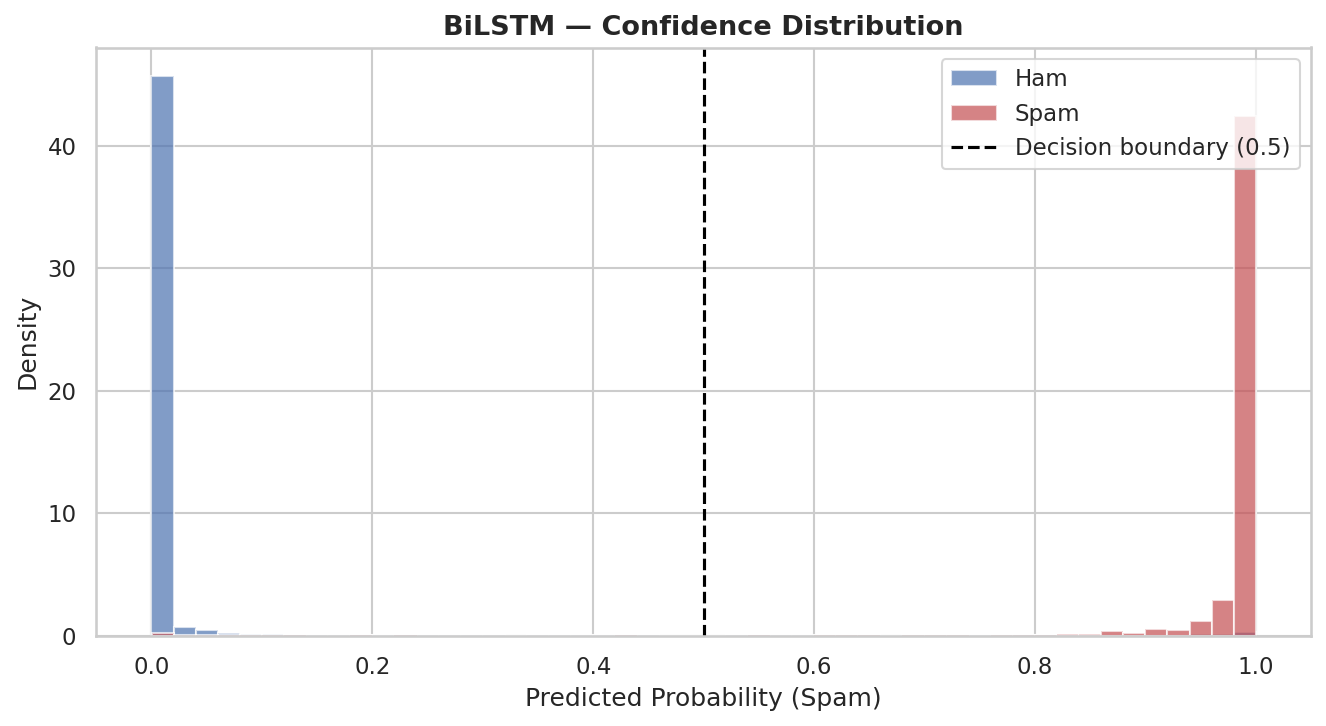

Saved: bilstm_confidence_dist.png


In [14]:
# Chart — BiLSTM Confidence Distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(proba[y_test==0], bins=50, color='#4C72B0', alpha=0.7, label='Ham',  density=True)
ax.hist(proba[y_test==1], bins=50, color='#C44E52', alpha=0.7, label='Spam', density=True)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Decision boundary (0.5)')
ax.set_xlabel('Predicted Probability (Spam)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('BiLSTM — Confidence Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('charts/bilstm_confidence_dist.png')
plt.show()
print('Saved: bilstm_confidence_dist.png')

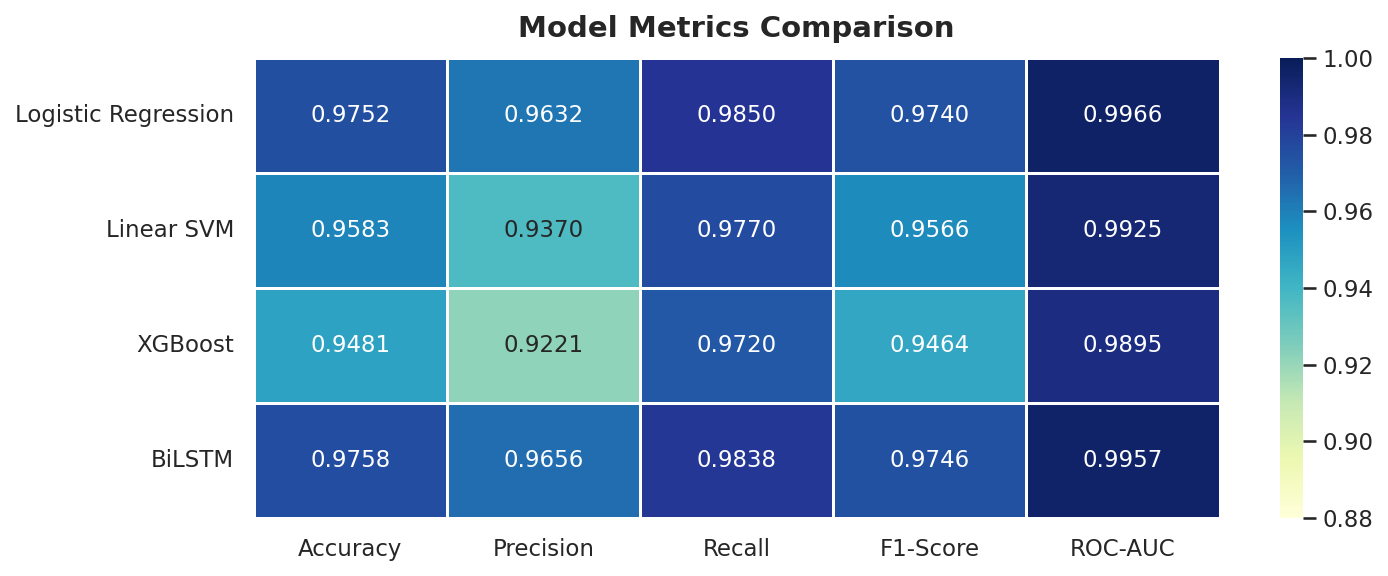

Saved: metrics_heatmap.png


In [15]:
# Chart — Metrics Heatmap (all 4 models)
metric_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
data = [[METRICS[m][c] for c in metric_cols] for m in MODELS]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(data, annot=True, fmt='.4f', cmap='YlGnBu',
            xticklabels=metric_cols, yticklabels=MODELS,
            linewidths=0.5, linecolor='white', vmin=0.88, vmax=1.0, ax=ax,
            annot_kws={'size':11})
ax.set_title('Model Metrics Comparison', fontsize=14, fontweight='bold', pad=10)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11, rotation=0)
plt.tight_layout()
plt.savefig('charts/metrics_heatmap.png')
plt.show()
print('Saved: metrics_heatmap.png')

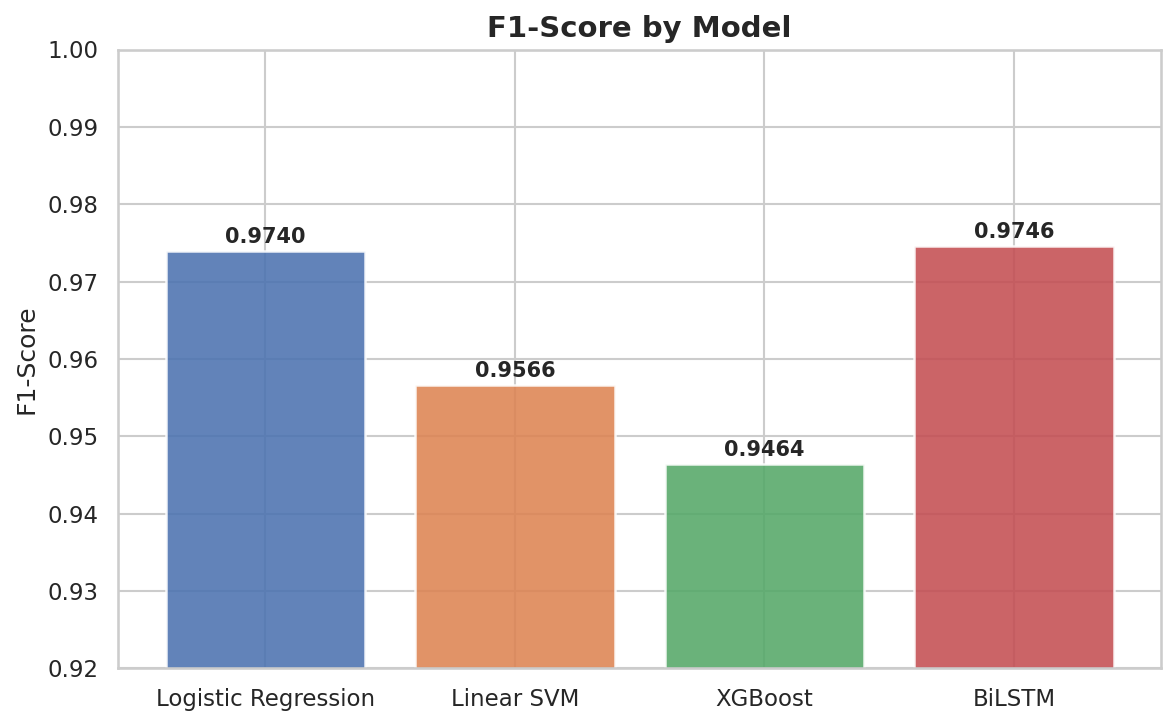

Saved: charts/f1_bar.png


In [16]:
# Chart — F1-Score Bar
f1s  = [METRICS[m]['F1-Score'] for m in MODELS]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(MODELS, f1s, color=COLOURS, edgecolor='white', linewidth=1.2, alpha=0.88)
ax.set_ylim(0.92, 1.0)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('F1-Score by Model', fontsize=14, fontweight='bold')
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/f1_bar.png')
plt.show()
print('Saved: charts/f1_bar.png')

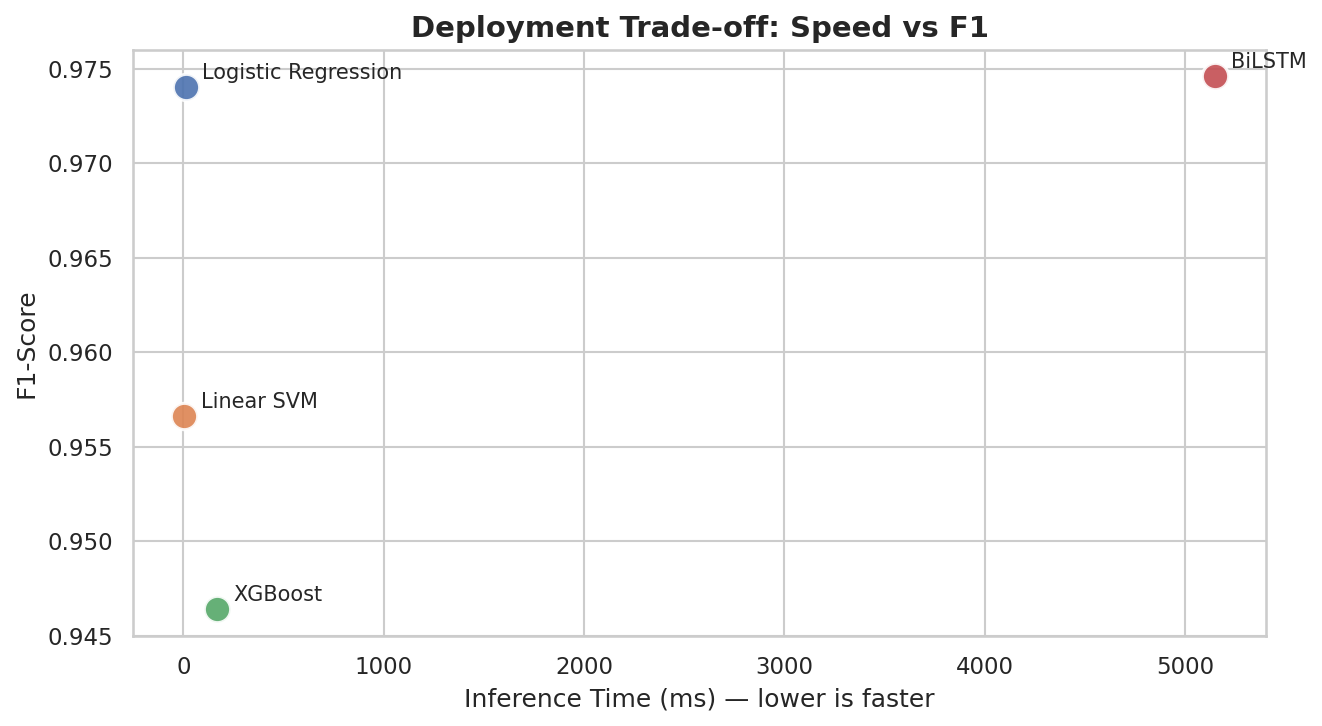

Saved: charts/speed_vs_f1.png


In [17]:
# Chart — Speed vs F1 Trade-off
fig, ax = plt.subplots(figsize=(9, 5))
for m, c in zip(MODELS, COLOURS):
    ax.scatter(METRICS[m]['Infer Time (ms)'], METRICS[m]['F1-Score'],
               s=160, color=c, zorder=3, alpha=0.9, edgecolors='white', linewidth=1.5)
    ax.annotate(m, (METRICS[m]['Infer Time (ms)'], METRICS[m]['F1-Score']),
                textcoords='offset points', xytext=(8, 4), fontsize=10)
ax.set_xlabel('Inference Time (ms) — lower is faster', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Deployment Trade-off: Speed vs F1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/speed_vs_f1.png')
plt.show()
print('Saved: charts/speed_vs_f1.png')

In [18]:
# Summary
print('\n=== All charts saved to charts/ ===')
for fname in sorted(os.listdir('charts')):
    if fname.endswith('.png'):
        kb = os.path.getsize(f'charts/{fname}') / 1024
        print(f'  {fname:<45} {kb:>6.1f} KB')


=== All charts saved to charts/ ===
  adversarial_robustness.png                      71.2 KB
  bilstm_confidence_dist.png                      45.0 KB
  bilstm_confusion_matrix.png                     37.8 KB
  bilstm_roc_curve.png                            54.7 KB
  bilstm_training_history.png                     97.0 KB
  f1_bar.png                                      46.7 KB
  metrics_heatmap.png                             87.3 KB
  speed_vs_f1.png                                 56.9 KB
